# 10 — Repeated Specimen-Grouped Robustness Validation

## Final experimental notebook

Notebook 09 found that acquisition-aware augmentation improved Swin-T unseen-specimen Macro-F1 from **0.7932 to 0.8074** on one physical-sample split.

A single grouped split is not enough to establish that the improvement is stable. This notebook therefore repeats the experiment across multiple **physical-specimen-disjoint** train/validation/test partitions.

### Questions

1. Does Swin-T consistently generalize better than the ResNet18 baseline on unseen physical specimens?
2. Does acquisition-aware augmentation consistently improve Swin-T?
3. How variable are the results when different physical specimens are held out?

### Models evaluated

- **ResNet18** — computationally efficient CNN transfer-learning baseline.
- **Swin-T** — strongest architecture from Notebook 08.
- **Swin-T + acquisition-aware augmentation** — best intervention from Notebook 09.

ViT-B/16 is not retrained here because its CPU cost was extremely high and it was already weaker than Swin-T on the original specimen-grouped test. Notebook 10 focuses compute on the two central claims.

### Statistical reporting

For each method we report mean ± standard deviation across grouped splits and a 95% t-based confidence interval. We also report **paired per-split differences**, which are more informative than comparing independent averages.

> With only 20 physical specimens and five repeated partitions, these intervals are descriptive rather than definitive population-level inference.


## 1. Configuration


In [1]:
from pathlib import Path

PROCESSED_DIR = Path(r"../data/processed")
MODEL_DIR = Path(r"../models/10_grouped_robustness")
RESULT_DIR = Path(r"../results/10_grouped_robustness")
MODEL_DIR.mkdir(parents=True, exist_ok=True)
RESULT_DIR.mkdir(parents=True, exist_ok=True)

# FULL = recommended final experiment.
# QUICK = smoke test to verify the notebook before an overnight run.
RUN_MODE = "FULL"

N_REPEATS = 5 if RUN_MODE == "FULL" else 1
BASE_SEEDS = [11, 29, 47, 71, 101][:N_REPEATS]

IMAGE_SIZE = 224
BATCH_SIZE = 16
NUM_WORKERS = 0          # safest for Windows/Jupyter
HEAD_EPOCHS = 3
FINETUNE_EPOCHS = 10 if RUN_MODE == "FULL" else 2
PATIENCE = 3
RESUME = True

# Number of physical specimens assigned to validation and test.
# With 20 samples this gives 14 train / 3 val / 3 test.
N_VAL_GROUPS = 3
N_TEST_GROUPS = 3

print("Run mode:", RUN_MODE)
print("Repeated grouped splits:", N_REPEATS)
print("Seeds:", BASE_SEEDS)


Run mode: FULL
Repeated grouped splits: 5
Seeds: [11, 29, 47, 71, 101]


## 2. Imports and reproducibility


In [2]:
import random, time, warnings, math, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from torchvision import transforms
from torchvision.models import (
    resnet18, ResNet18_Weights,
    swin_t, Swin_T_Weights
)

from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score,
    precision_score, recall_score, f1_score, roc_auc_score
)

warnings.filterwarnings("ignore")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def seed_everything(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

print("PyTorch:", torch.__version__)
print("Device :", device)


PyTorch: 2.14.0+cpu
Device : cpu


## 3. Load the cleaned modelling manifest

Notebook 02 produced `clean_manifest.csv` after image matching and duplicate removal. We use that clean dataset here and generate new specimen-grouped partitions.

No image from a physical specimen is allowed to appear in more than one split.


In [3]:
manifest_path = PROCESSED_DIR / "clean_manifest.csv"
assert manifest_path.exists(), f"Missing: {manifest_path}"

df = pd.read_csv(manifest_path)

required = {"image_path", "Phase", "SampleIDHarm"}
missing = required - set(df.columns)
assert not missing, f"Missing required columns: {missing}"

# Robust binary label creation.
phase_to_label = {"Bainite": 0, "Martensite": 1}
if "label" not in df.columns:
    df["label"] = df["Phase"].map(phase_to_label)

df = df[df["Phase"].isin(phase_to_label)].copy()
df["label"] = df["Phase"].map(phase_to_label).astype(int)

print("Images:", len(df))
print("Physical specimens:", df["SampleIDHarm"].nunique())
print(df["Phase"].value_counts())
print("\nImages/specimen:")
display(df.groupby("SampleIDHarm").size().sort_values(ascending=False).to_frame("n_images"))


Images: 5293
Physical specimens: 20
Phase
Martensite    2823
Bainite       2470
Name: count, dtype: int64

Images/specimen:


,n_images
SampleIDHarm,
D,683
C,444
A,333
B,304
L,266
J,228
R,228
Q,228
O,228


## 4. Generate repeated leakage-safe specimen partitions

The same physical specimen is kept entirely inside train, validation, or test.

To avoid pathological partitions, candidate splits are searched until:
- all three partitions contain both classes,
- group overlap is exactly zero,
- test-set class balance is reasonably close to the full dataset.

Different repeat seeds produce different held-out physical specimens.


In [4]:
def valid_class_coverage(part):
    return part["label"].nunique() == 2

def build_grouped_split(data, seed, n_val=N_VAL_GROUPS, n_test=N_TEST_GROUPS):
    groups = np.array(sorted(data["SampleIDHarm"].astype(str).unique()))
    rng = np.random.default_rng(seed)

    best = None
    overall_p = data["label"].mean()

    # Search deterministic candidates generated from this repeat seed.
    for attempt in range(5000):
        perm = rng.permutation(groups)
        test_g = set(perm[:n_test])
        val_g  = set(perm[n_test:n_test+n_val])
        train_g = set(perm[n_test+n_val:])

        out = data.copy()
        out["split"] = "train"
        out.loc[out["SampleIDHarm"].astype(str).isin(val_g), "split"] = "val"
        out.loc[out["SampleIDHarm"].astype(str).isin(test_g), "split"] = "test"

        parts = {s: out[out["split"] == s] for s in ["train","val","test"]}
        if not all(valid_class_coverage(x) for x in parts.values()):
            continue

        # Score candidate by class-balance similarity + image-count balance.
        balance_penalty = sum(abs(x["label"].mean() - overall_p) for x in parts.values())
        size_penalty = abs(len(parts["test"])/len(out) - n_test/len(groups))
        score = balance_penalty + 0.25*size_penalty

        if best is None or score < best[0]:
            best = (score, out, train_g, val_g, test_g)

        if score < 0.08:
            break

    if best is None:
        raise RuntimeError(f"Could not create valid grouped split for seed {seed}")

    _, out, train_g, val_g, test_g = best

    assert train_g.isdisjoint(val_g)
    assert train_g.isdisjoint(test_g)
    assert val_g.isdisjoint(test_g)

    return out

split_frames = {}
audit_rows = []

for i, seed in enumerate(BASE_SEEDS, 1):
    sdf = build_grouped_split(df, seed)
    split_frames[i] = sdf

    for split in ["train","val","test"]:
        x = sdf[sdf["split"] == split]
        audit_rows.append({
            "repeat": i, "seed": seed, "split": split,
            "n_images": len(x),
            "n_samples": x["SampleIDHarm"].nunique(),
            "bainite": int((x["label"]==0).sum()),
            "martensite": int((x["label"]==1).sum()),
            "samples": ", ".join(sorted(x["SampleIDHarm"].astype(str).unique()))
        })

audit = pd.DataFrame(audit_rows)
display(audit)
audit.to_csv(RESULT_DIR / "grouped_split_audit.csv", index=False)

# Save every split so the exact experiment is reproducible.
for i, sdf in split_frames.items():
    sdf.to_csv(RESULT_DIR / f"repeat_{i:02d}_split.csv", index=False)


,repeat,seed,split,n_images,n_samples,bainite,martensite,samples
0,1,11,train,3944,14,1805,2139,"A, B, C, D, E, G, H, I, J, K, M, Q, S, T"
1,1,11,val,722,3,342,380,"F, L, O"
2,1,11,test,627,3,323,304,"N, P, R"
3,2,29,train,3963,14,1862,2101,"A, B, C, D, E, G, H, I, J, K, Q, R, S, T"
4,2,29,val,608,3,266,342,"M, N, P"
5,2,29,test,722,3,342,380,"F, L, O"
6,3,47,train,3763,14,1735,2028,"C, D, E, F, H, J, L, N, O, P, Q, R, S, T"
7,3,47,val,760,3,342,418,"B, G, K"
8,3,47,test,770,3,393,377,"A, I, M"
9,4,71,train,3801,14,1811,1990,"C, D, E, G, H, I, J, L, M, O, Q, R, S, T"


## 5. Image preprocessing and datasets


In [5]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

reference_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

# Best NB09 intervention.
acquisition_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.RandomAffine(
        degrees=0, translate=(0.05, 0.05), scale=(0.90, 1.10)
    ),
    transforms.ColorJitter(brightness=0.20, contrast=0.20),
    transforms.RandomApply(
        [transforms.GaussianBlur(3, sigma=(0.1, 1.0))], p=0.20
    ),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

eval_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

class MicrostructureDataset(Dataset):
    def __init__(self, frame, transform):
        self.frame = frame.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.frame)

    def __getitem__(self, idx):
        row = self.frame.iloc[idx]
        p = Path(str(row["image_path"]))

        # Notebook 02 may store absolute paths or paths relative to the project.
        if not p.exists():
            candidates = [
                Path.cwd() / p,
                Path.cwd().parent / p,
                PROCESSED_DIR.parent.parent / p,
            ]
            found = next((q for q in candidates if q.exists()), None)
            if found is None:
                raise FileNotFoundError(f"Image not found: {p}")
            p = found

        with Image.open(p) as im:
            im = im.convert("RGB")
            x = self.transform(im)

        return x, int(row["label"])

def make_loaders(sdf, train_tf, seed):
    parts = {s: sdf[sdf["split"]==s].copy() for s in ["train","val","test"]}
    datasets = {
        "train": MicrostructureDataset(parts["train"], train_tf),
        "val": MicrostructureDataset(parts["val"], eval_transform),
        "test": MicrostructureDataset(parts["test"], eval_transform),
    }
    common = dict(batch_size=BATCH_SIZE, num_workers=NUM_WORKERS,
                  pin_memory=torch.cuda.is_available())

    g = torch.Generator().manual_seed(seed)
    loaders = {
        "train": DataLoader(datasets["train"], shuffle=True, generator=g, **common),
        "val": DataLoader(datasets["val"], shuffle=False, **common),
        "test": DataLoader(datasets["test"], shuffle=False, **common),
    }
    return loaders


## 6. Models

Both architectures use ImageNet-pretrained weights.

To keep repeated CPU validation feasible:
- Stage 1 trains only the classifier head.
- Stage 2 fine-tunes only the final high-level block/stage.

This is a repeated-validation experiment, not a new hyperparameter search.


In [6]:
RESNET_WEIGHTS = ResNet18_Weights.DEFAULT
SWIN_WEIGHTS = Swin_T_Weights.DEFAULT

def build_resnet():
    m = resnet18(weights=RESNET_WEIGHTS)
    m.fc = nn.Linear(m.fc.in_features, 2)
    return m

def configure_resnet_head(m):
    for p in m.parameters(): p.requires_grad = False
    for p in m.fc.parameters(): p.requires_grad = True

def configure_resnet_finetune(m):
    for p in m.parameters(): p.requires_grad = False
    for p in m.layer4.parameters(): p.requires_grad = True
    for p in m.fc.parameters(): p.requires_grad = True

def build_swin():
    m = swin_t(weights=SWIN_WEIGHTS)
    m.head = nn.Linear(m.head.in_features, 2)
    return m

def configure_swin_head(m):
    for p in m.parameters(): p.requires_grad = False
    for p in m.head.parameters(): p.requires_grad = True

def configure_swin_finetune(m):
    for p in m.parameters(): p.requires_grad = False
    # final Swin feature stage + normalization + head
    for p in m.features[-1].parameters(): p.requires_grad = True
    for p in m.norm.parameters(): p.requires_grad = True
    for p in m.head.parameters(): p.requires_grad = True

MODEL_SPECS = {
    "resnet18": {
        "build": build_resnet,
        "head": configure_resnet_head,
        "fine": configure_resnet_finetune,
        "head_lr": 1e-3,
        "fine_lr": 2e-5,
    },
    "swin_t": {
        "build": build_swin,
        "head": configure_swin_head,
        "fine": configure_swin_finetune,
        "head_lr": 1e-3,
        "fine_lr": 2e-5,
    }
}


## 7. Metrics and evaluation


In [7]:
def classification_metrics(y_true, y_pred, y_prob):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "precision_macro": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "recall_macro": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "f1_macro": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_prob),
    }

@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    losses, ys, preds, probs = [], [], [], []

    for x, y in loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        loss = criterion(logits, y)
        pr = torch.softmax(logits, dim=1)[:,1]
        pd_ = logits.argmax(1)

        losses.append(loss.item() * len(y))
        ys.extend(y.cpu().numpy())
        preds.extend(pd_.cpu().numpy())
        probs.extend(pr.cpu().numpy())

    m = classification_metrics(np.array(ys), np.array(preds), np.array(probs))
    m["loss"] = sum(losses) / len(ys)
    return m


## 8. Crash-safe two-stage training


In [8]:
def train_stage(model, loaders, criterion, optimizer, scheduler,
                start_epoch, n_epochs, patience, best_f1,
                best_path, latest_path, stage_name):

    bad = 0
    best_epoch = start_epoch - 1

    for epoch in range(start_epoch, start_epoch + n_epochs):
        model.train()
        ys, preds = [], []

        for x, y in loaders["train"]:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad(set_to_none=True)
            logits = model(x)
            loss = criterion(logits, y)
            loss.backward()
            optimizer.step()

            ys.extend(y.detach().cpu().numpy())
            preds.extend(logits.argmax(1).detach().cpu().numpy())

        train_f1 = f1_score(ys, preds, average="macro", zero_division=0)
        val = evaluate(model, loaders["val"], criterion)
        lr = optimizer.param_groups[0]["lr"]

        print(
            f"Epoch {epoch:02d} | {stage_name:<9} | "
            f"train F1 {train_f1:.4f} | val F1 {val['f1_macro']:.4f} | "
            f"val AUC {val['roc_auc']:.4f} | lr {lr:.1e}"
        )

        improved = val["f1_macro"] > best_f1 + 1e-5
        if improved:
            best_f1 = val["f1_macro"]
            best_epoch = epoch
            bad = 0
            torch.save({
                "model_state_dict": model.state_dict(),
                "best_f1": best_f1,
                "epoch": epoch,
                "stage": stage_name,
            }, best_path)
        else:
            bad += 1

        torch.save({
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "epoch": epoch,
            "best_f1": best_f1,
            "stage": stage_name,
        }, latest_path)

        scheduler.step(val["f1_macro"])

        if bad >= patience:
            print(f"Early stopping {stage_name}.")
            break

    return best_f1, best_epoch

def run_training(experiment_name, model_key, sdf, train_tf, seed):
    seed_everything(seed)
    loaders = make_loaders(sdf, train_tf, seed)
    spec = MODEL_SPECS[model_key]

    best_path = MODEL_DIR / f"{experiment_name}_best.pt"
    latest_path = MODEL_DIR / f"{experiment_name}_latest.pt"

    # If a completed best checkpoint exists and results were already written,
    # the outer loop will skip the experiment.
    model = spec["build"]().to(device)
    criterion = nn.CrossEntropyLoss()

    t0 = time.time()

    # Stage 1: head
    spec["head"](model)
    optimizer = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=spec["head_lr"], weight_decay=1e-4
    )
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="max", factor=0.5, patience=1
    )

    best_f1, best_epoch = train_stage(
        model, loaders, criterion, optimizer, scheduler,
        1, HEAD_EPOCHS, PATIENCE, -np.inf,
        best_path, latest_path, "head"
    )

    # Reload best head before fine tuning.
    ck = torch.load(best_path, map_location=device, weights_only=False)
    model.load_state_dict(ck["model_state_dict"])

    # Stage 2: final block/stage
    spec["fine"](model)
    optimizer = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=spec["fine_lr"], weight_decay=1e-4
    )
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="max", factor=0.5, patience=2
    )

    best_f1, fine_best_epoch = train_stage(
        model, loaders, criterion, optimizer, scheduler,
        HEAD_EPOCHS + 1, FINETUNE_EPOCHS, PATIENCE,
        best_f1, best_path, latest_path, "fine_tune"
    )
    if fine_best_epoch >= HEAD_EPOCHS + 1:
        best_epoch = fine_best_epoch

    # Test only the validation-selected best checkpoint.
    ck = torch.load(best_path, map_location=device, weights_only=False)
    model.load_state_dict(ck["model_state_dict"])
    test = evaluate(model, loaders["test"], criterion)

    minutes = (time.time() - t0) / 60
    return test, best_epoch, minutes


## 9. Run repeated grouped validation

This is the long-running cell.

There are **3 methods × 5 grouped partitions = 15 training runs** in FULL mode. On CPU this may take many hours.

The notebook writes `running_results.csv` after every completed run. If the kernel stops, rerun the setup cells and this cell; completed experiments will be skipped automatically.


In [9]:
METHODS = {
    "ResNet18": ("resnet18", reference_transform),
    "Swin-T": ("swin_t", reference_transform),
    "Swin-T + AcquisitionAug": ("swin_t", acquisition_transform),
}

running_csv = RESULT_DIR / "running_results.csv"

if running_csv.exists() and RESUME:
    results_df = pd.read_csv(running_csv)
else:
    results_df = pd.DataFrame()

completed = set()
if len(results_df):
    completed = set(zip(results_df["repeat"].astype(int), results_df["method"].astype(str)))

for repeat, seed in enumerate(BASE_SEEDS, 1):
    sdf = split_frames[repeat]
    print("\n" + "="*92)
    print(f"GROUPED REPEAT {repeat}/{N_REPEATS} | seed={seed}")
    print("="*92)

    test_samples = sorted(
        sdf.loc[sdf["split"]=="test", "SampleIDHarm"].astype(str).unique()
    )
    print("Held-out test specimens:", test_samples)

    for method, (model_key, tf) in METHODS.items():
        if (repeat, method) in completed:
            print(f"\n✓ Skipping completed: repeat {repeat} | {method}")
            continue

        exp_name = f"repeat_{repeat:02d}_{method.lower().replace(' ','_').replace('+','plus')}"
        print(f"\n--- {method} ---")

        test, best_epoch, minutes = run_training(
            exp_name, model_key, sdf, tf, seed
        )

        row = {
            "repeat": repeat,
            "seed": seed,
            "method": method,
            "test_samples": "|".join(test_samples),
            "accuracy": test["accuracy"],
            "balanced_accuracy": test["balanced_accuracy"],
            "precision_macro": test["precision_macro"],
            "recall_macro": test["recall_macro"],
            "f1_macro": test["f1_macro"],
            "roc_auc": test["roc_auc"],
            "loss": test["loss"],
            "best_val_epoch": best_epoch,
            "runtime_min": minutes,
        }

        results_df = pd.concat(
            [results_df, pd.DataFrame([row])], ignore_index=True
        )
        results_df.to_csv(running_csv, index=False)
        completed.add((repeat, method))

        print("TEST")
        print(f"  Macro-F1          : {test['f1_macro']:.4f}")
        print(f"  Balanced Accuracy : {test['balanced_accuracy']:.4f}")
        print(f"  ROC-AUC           : {test['roc_auc']:.4f}")
        print(f"  Runtime           : {minutes:.1f} min")

print("\n✓ Repeated grouped validation completed.")



GROUPED REPEAT 1/5 | seed=11
Held-out test specimens: ['N', 'P', 'R']

✓ Skipping completed: repeat 1 | ResNet18

✓ Skipping completed: repeat 1 | Swin-T

✓ Skipping completed: repeat 1 | Swin-T + AcquisitionAug

GROUPED REPEAT 2/5 | seed=29
Held-out test specimens: ['F', 'L', 'O']

--- ResNet18 ---
Epoch 01 | head      | train F1 0.6804 | val F1 0.4878 | val AUC 0.6607 | lr 1.0e-03
Epoch 02 | head      | train F1 0.7408 | val F1 0.6114 | val AUC 0.6724 | lr 1.0e-03
Epoch 03 | head      | train F1 0.7607 | val F1 0.6076 | val AUC 0.6756 | lr 1.0e-03
Epoch 04 | fine_tune | train F1 0.7970 | val F1 0.5931 | val AUC 0.7235 | lr 2.0e-05
Epoch 05 | fine_tune | train F1 0.8367 | val F1 0.5714 | val AUC 0.7262 | lr 2.0e-05
Epoch 06 | fine_tune | train F1 0.8726 | val F1 0.6517 | val AUC 0.7408 | lr 2.0e-05
Epoch 07 | fine_tune | train F1 0.8903 | val F1 0.6468 | val AUC 0.7462 | lr 2.0e-05
Epoch 08 | fine_tune | train F1 0.8964 | val F1 0.6496 | val AUC 0.7405 | lr 2.0e-05
Epoch 09 | fine_tu

## 10. Aggregate performance across specimen partitions


In [10]:
results_df = pd.read_csv(running_csv)

# Require a complete matrix before final statistics.
expected = N_REPEATS * len(METHODS)
print(f"Completed runs: {len(results_df)} / {expected}")

display(results_df.sort_values(["repeat","method"]))

def t_ci(values, confidence=0.95):
    values = np.asarray(values, dtype=float)
    n = len(values)
    mean = values.mean()
    if n < 2:
        return mean, np.nan, np.nan, np.nan

    sd = values.std(ddof=1)
    # t critical values for df 1..30 at 95%; scipy-free fallback.
    t95 = {
        1:12.706,2:4.303,3:3.182,4:2.776,5:2.571,6:2.447,7:2.365,
        8:2.306,9:2.262,10:2.228,11:2.201,12:2.179,13:2.160,
        14:2.145,15:2.131,16:2.120,17:2.110,18:2.101,19:2.093,
        20:2.086,21:2.080,22:2.074,23:2.069,24:2.064,25:2.060,
        26:2.056,27:2.052,28:2.048,29:2.045,30:2.042
    }
    tcrit = t95.get(n-1, 1.96)
    half = tcrit * sd / np.sqrt(n)
    return mean, sd, mean-half, mean+half

summary_rows=[]
for method, g in results_df.groupby("method"):
    row={"method":method,"n_repeats":len(g)}
    for metric in ["accuracy","balanced_accuracy","f1_macro","roc_auc"]:
        mean, sd, lo, hi = t_ci(g[metric])
        row[f"{metric}_mean"]=mean
        row[f"{metric}_sd"]=sd
        row[f"{metric}_ci_low"]=lo
        row[f"{metric}_ci_high"]=hi
    summary_rows.append(row)

summary = pd.DataFrame(summary_rows).sort_values("f1_macro_mean", ascending=False)
summary.to_csv(RESULT_DIR / "aggregate_statistics.csv", index=False)

display(summary[[
    "method","n_repeats",
    "f1_macro_mean","f1_macro_sd","f1_macro_ci_low","f1_macro_ci_high",
    "balanced_accuracy_mean","roc_auc_mean"
]].style.format({
    "f1_macro_mean":"{:.4f}","f1_macro_sd":"{:.4f}",
    "f1_macro_ci_low":"{:.4f}","f1_macro_ci_high":"{:.4f}",
    "balanced_accuracy_mean":"{:.4f}","roc_auc_mean":"{:.4f}"
}))


Completed runs: 15 / 15


,repeat,seed,method,test_samples,accuracy,balanced_accuracy,precision_macro,recall_macro,f1_macro,roc_auc,loss,best_val_epoch,runtime_min
0,1,11,ResNet18,N|P|R,0.792663,0.794601,0.797939,0.794601,0.792333,0.869674,0.503400,8,43.713313
1,1,11,Swin-T,N|P|R,0.824561,0.826045,0.827747,0.826045,0.824461,0.920299,0.380776,7,83.147846
2,1,11,Swin-T + AcquisitionAug,N|P|R,0.779904,0.782411,0.788499,0.782411,0.779135,0.901438,0.428757,7,89.212908
3,2,29,ResNet18,F|L|O,0.785319,0.778363,0.803783,0.778363,0.778685,0.854094,0.606039,6,32.265416
4,2,29,Swin-T,F|L|O,0.752078,0.741667,0.792929,0.741667,0.737344,0.852893,0.593672,3,45.623151
5,2,29,Swin-T + AcquisitionAug,F|L|O,0.775623,0.770614,0.783438,0.770614,0.771412,0.844829,0.526500,3,46.585198
6,3,47,ResNet18,A|I|M,0.645455,0.645814,0.645870,0.645814,0.645449,0.696587,1.024134,8,38.355896
7,3,47,Swin-T,A|I|M,0.650649,0.651767,0.653275,0.651767,0.650082,0.678080,0.844727,2,47.221664
8,3,47,Swin-T + AcquisitionAug,A|I|M,0.662338,0.662624,0.662624,0.662624,0.662338,0.686456,0.990246,4,55.747428
9,4,71,ResNet18,B|K|P,0.774238,0.771345,0.775886,0.771345,0.772157,0.859703,0.558082,10,46.388813


,method,n_repeats,f1_macro_mean,f1_macro_sd,f1_macro_ci_low,f1_macro_ci_high,balanced_accuracy_mean,roc_auc_mean
1,Swin-T,5,0.7769,0.0826,0.6744,0.8794,0.7782,0.8563
2,Swin-T + AcquisitionAug,5,0.7703,0.0643,0.6905,0.8501,0.7708,0.8491
0,ResNet18,5,0.7601,0.0659,0.6783,0.8419,0.7601,0.8330


## 11. Paired split-by-split comparisons

Because all methods are evaluated on the **same held-out specimens within each repeat**, paired differences are the most useful comparison.

Primary comparisons:
- Swin-T − ResNet18
- Swin-T + AcquisitionAug − Swin-T

A positive difference means the method on the left performed better on that repeat.


In [11]:
pivot = results_df.pivot(index="repeat", columns="method", values="f1_macro")

paired_rows = []
comparisons = [
    ("Swin-T", "ResNet18", "Swin-T − ResNet18"),
    ("Swin-T + AcquisitionAug", "Swin-T", "AcqAug − Swin-T"),
]

for a,b,label in comparisons:
    if a not in pivot.columns or b not in pivot.columns:
        continue
    d = (pivot[a] - pivot[b]).dropna()
    mean, sd, lo, hi = t_ci(d.values)
    paired_rows.append({
        "comparison": label,
        "n_pairs": len(d),
        "mean_delta_f1": mean,
        "sd_delta": sd,
        "ci_low": lo,
        "ci_high": hi,
        "positive_repeats": int((d > 0).sum()),
        "negative_repeats": int((d < 0).sum()),
        "ties": int((d == 0).sum()),
    })

paired = pd.DataFrame(paired_rows)
paired.to_csv(RESULT_DIR / "paired_f1_differences.csv", index=False)
display(paired.style.format({
    "mean_delta_f1":"{:+.4f}",
    "sd_delta":"{:.4f}",
    "ci_low":"{:+.4f}",
    "ci_high":"{:+.4f}"
}))

print("\nPer-repeat Macro-F1:")
display(pivot)


,comparison,n_pairs,mean_delta_f1,sd_delta,ci_low,ci_high,positive_repeats,negative_repeats,ties
0,Swin-T − ResNet18,5,+0.0168,0.0367,-0.0287,+0.0623,4,1,0
1,AcqAug − Swin-T,5,-0.0066,0.0317,-0.0459,+0.0327,2,3,0



Per-repeat Macro-F1:


method,ResNet18,Swin-T,Swin-T + AcquisitionAug
repeat,,,
1,0.792333,0.824461,0.779135
2,0.778685,0.737344,0.771412
3,0.645449,0.650082,0.662338
4,0.772157,0.823637,0.818531
5,0.811871,0.848958,0.819999


## 12. Final report figures


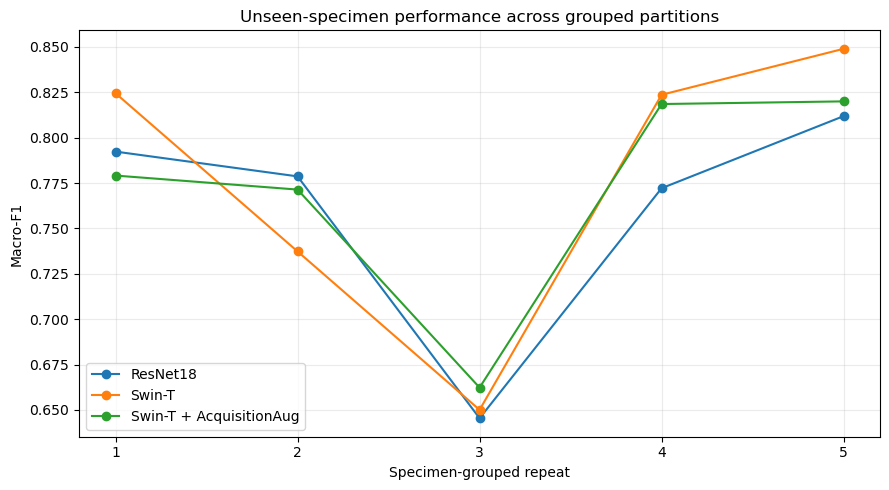

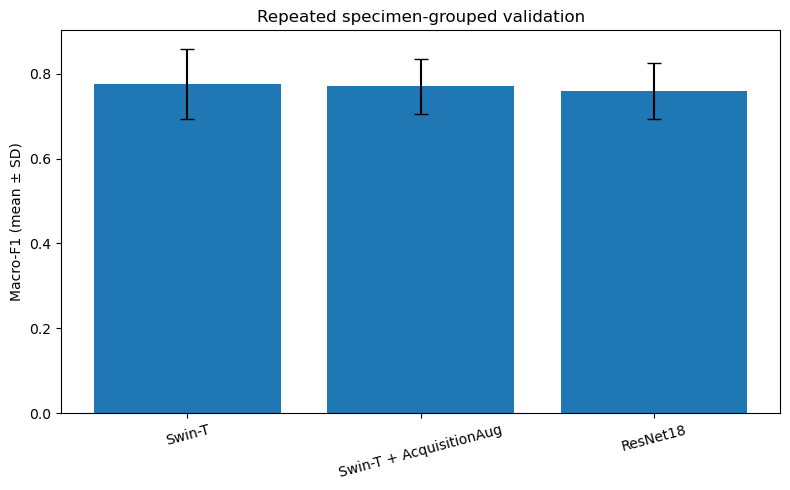

In [12]:
# Figure 1: Macro-F1 by grouped repeat
fig, ax = plt.subplots(figsize=(9,5))
for method in METHODS:
    g = results_df[results_df["method"]==method].sort_values("repeat")
    ax.plot(g["repeat"], g["f1_macro"], marker="o", label=method)

ax.set_xlabel("Specimen-grouped repeat")
ax.set_ylabel("Macro-F1")
ax.set_title("Unseen-specimen performance across grouped partitions")
ax.set_xticks(range(1, N_REPEATS+1))
ax.grid(alpha=0.25)
ax.legend()
fig.tight_layout()
fig.savefig(RESULT_DIR / "f1_across_grouped_repeats.png", dpi=300, bbox_inches="tight")
plt.show()

# Figure 2: mean ± SD
order = list(summary.sort_values("f1_macro_mean", ascending=False)["method"])
means = [summary.set_index("method").loc[m,"f1_macro_mean"] for m in order]
sds = [summary.set_index("method").loc[m,"f1_macro_sd"] for m in order]

fig, ax = plt.subplots(figsize=(8,5))
ax.bar(order, means, yerr=sds, capsize=5)
ax.set_ylabel("Macro-F1 (mean ± SD)")
ax.set_title("Repeated specimen-grouped validation")
ax.tick_params(axis="x", rotation=15)
fig.tight_layout()
fig.savefig(RESULT_DIR / "mean_f1_grouped_validation.png", dpi=300, bbox_inches="tight")
plt.show()


## 13. Final statistical validation summary


In [13]:
print("="*96)
print("NOTEBOOK 10 — REPEATED SPECIMEN-GROUPED ROBUSTNESS VALIDATION")
print("="*96)

for _, r in summary.iterrows():
    print(f"\n{r['method']}")
    print(f"  Repeats              : {int(r['n_repeats'])}")
    print(f"  Macro-F1             : {r['f1_macro_mean']:.4f} ± {r['f1_macro_sd']:.4f}")
    print(f"  95% CI               : [{r['f1_macro_ci_low']:.4f}, {r['f1_macro_ci_high']:.4f}]")
    print(f"  Balanced Accuracy    : {r['balanced_accuracy_mean']:.4f}")
    print(f"  ROC-AUC              : {r['roc_auc_mean']:.4f}")

print("\nPAIRED MACRO-F1 DIFFERENCES")
for _, r in paired.iterrows():
    print(f"\n{r['comparison']}")
    print(f"  Mean ΔF1             : {r['mean_delta_f1']:+.4f}")
    print(f"  95% CI               : [{r['ci_low']:+.4f}, {r['ci_high']:+.4f}]")
    print(f"  Positive repeats     : {int(r['positive_repeats'])}/{int(r['n_pairs'])}")

print("\nINTERPRETATION RULE")
print("Do not claim universal superiority from five repeats.")
print("Use the paired direction, variability, and confidence interval to describe stability.")
print("\nEXPERIMENTAL PIPELINE COMPLETE.")
print("Next step: freeze results and write the LaTeX report.")
print("="*96)


NOTEBOOK 10 — REPEATED SPECIMEN-GROUPED ROBUSTNESS VALIDATION

Swin-T
  Repeats              : 5
  Macro-F1             : 0.7769 ± 0.0826
  95% CI               : [0.6744, 0.8794]
  Balanced Accuracy    : 0.7782
  ROC-AUC              : 0.8563

Swin-T + AcquisitionAug
  Repeats              : 5
  Macro-F1             : 0.7703 ± 0.0643
  95% CI               : [0.6905, 0.8501]
  Balanced Accuracy    : 0.7708
  ROC-AUC              : 0.8491

ResNet18
  Repeats              : 5
  Macro-F1             : 0.7601 ± 0.0659
  95% CI               : [0.6783, 0.8419]
  Balanced Accuracy    : 0.7601
  ROC-AUC              : 0.8330

PAIRED MACRO-F1 DIFFERENCES

Swin-T − ResNet18
  Mean ΔF1             : +0.0168
  95% CI               : [-0.0287, +0.0623]
  Positive repeats     : 4/5

AcqAug − Swin-T
  Mean ΔF1             : -0.0066
  95% CI               : [-0.0459, +0.0327]
  Positive repeats     : 2/5

INTERPRETATION RULE
Do not claim universal superiority from five repeats.
Use the paired direct

## 14. How to interpret Notebook 10 in the report

### If Swin-T is better than ResNet18 in most/all repeats
The architecture-dependent generalization result from the original split is supported across multiple specimen partitions.

### If acquisition augmentation improves Swin-T in most/all repeats
Notebook 09's robustness intervention is supported beyond one held-out specimen set.

### If rankings change substantially across repeats
This is still an important result: performance estimates are highly sensitive to which physical specimens are held out, and a single image-level or specimen-level split is insufficient for reliable model comparison.

### Important limitations

- These are repeated internal grouped splits, **not an independent external laboratory dataset**.
- Only 20 physical specimen IDs are available.
- Five repeats quantify split sensitivity but do not establish population-level certainty.
- Acquisition augmentation approximates plausible image variation; it is not a calibrated physical microscope model.
- Hyperparameters were not re-optimized independently for every repeat, intentionally avoiding test-specific tuning.
